In [1]:
# TÍTULO: Inferencia, Recorte y Benchmarking - Detector de Placas
# OBJETIVO: Validar el modelo, generar recortes para OCR y medir rendimiento de hardware.

from ultralytics import YOLO
import cv2
import os
import glob
import time
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm

# --- RUTAS DE PROYECTO ---
# Carpeta donde se guardaron los entrenamientos
MODELS_DIR = '../../models/02_placas'

# IMPORTANTE: Define aquí el nombre de la carpeta del entrenamiento que quieres probar
# (Debe coincidir con lo que generó el notebook 02_Training)
# Ejemplo: '20231027_v8n_clean_tl_640'
# Si no recuerdas el nombre exacto, el código abajo intentará buscar el más reciente.
RUN_NAME = 'AUTO_DETECT' 

# Ruta de imágenes de prueba (Usamos el test set del dataset de placas)
TEST_IMAGES_DIR = '../../datasets/02_placas/test/images'

# Salida: Donde guardaremos los recortes de las placas (Input para OCR)
OUTPUT_CROPS_DIR = '../../data/processed/plate_crops_test'

print("Entorno configurado.")

Entorno configurado.


In [2]:
def load_best_model(models_dir, specific_run=None):
    target_run = specific_run
    
    # Si está en auto, buscar la carpeta más reciente
    if specific_run == 'AUTO_DETECT':
        runs = sorted(glob.glob(os.path.join(models_dir, '*clean*'))) # Priorizamos el clean
        if not runs:
             runs = sorted(glob.glob(os.path.join(models_dir, '*')))
        
        if runs:
            target_run = os.path.basename(runs[-1])
            print(f"Modo Auto: Seleccionado el último run -> '{target_run}'")
        else:
            raise FileNotFoundError(f"No se encontraron modelos en {models_dir}")

    # Construir ruta al archivo de pesos
    weights_path = os.path.join(models_dir, target_run, 'weights', 'best.pt')
    
    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"No se encuentra el archivo: {weights_path}")
    
    print(f"Cargando modelo desde: {weights_path}")
    return YOLO(weights_path)

In [5]:
# Cargar 100_v11n_resplit_tl
try:
    # model = load_best_model(MODELS_DIR, RUN_NAME)
    RUN_NAME = '100_v11n_resplit_tl'
    model = load_best_model(MODELS_DIR, RUN_NAME)
    print("Modelo cargado exitosamente.")
    # benchmark_performance(TEST_IMAGES_DIR, model=model_100_v11n_resplit_tl)
except Exception as e:
    print(e)

Cargando modelo desde: ../../models/02_placas/100_v11n_resplit_tl/weights/best.pt
Modelo cargado exitosamente.


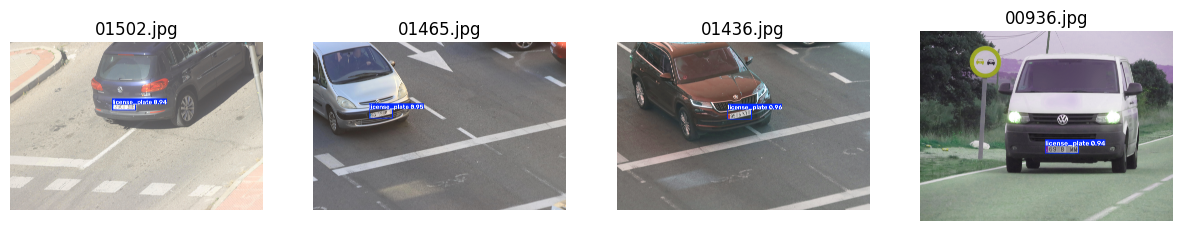

In [6]:
import random

# Buscar imágenes
images = glob.glob(os.path.join(TEST_IMAGES_DIR, '*.jpg'))
if not images: images = glob.glob(os.path.join(TEST_IMAGES_DIR, '*.png'))

if images:
    # Seleccionar 4 al azar
    samples = random.sample(images, min(4, len(images)))
    
    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(samples):
        # Inferencia
        results = model.predict(img_path, conf=0.25, verbose=False)
        
        # Plotear
        res_plot = results[0].plot()
        
        plt.subplot(1, 4, i+1)
        plt.imshow(cv2.cvtColor(res_plot, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(os.path.basename(img_path))
    plt.show()
else:
    print("No se encontraron imágenes en el directorio de test.")

Generando recortes de placas de 100 imágenes...


  0%|          | 0/100 [00:00<?, ?it/s]

Se guardaron 129 recortes de placas en: ../../data/processed/plate_crops_test


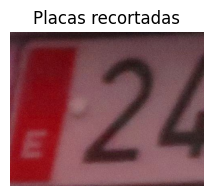

In [9]:
import shutil 

def generate_ocr_crops(source_dir, output_dir, conf_threshold=0.25):
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir, exist_ok=True)
    
    image_paths = glob.glob(os.path.join(source_dir, '*'))
    valid_exts = ('.jpg', '.jpeg', '.png')
    image_paths = [p for p in image_paths if p.lower().endswith(valid_exts)]
    
    print(f"Generando recortes de placas de {len(image_paths)} imágenes...")
    
    count_crops = 0
    
    for img_path in tqdm(image_paths):
        # Inferencia
        results = model.predict(img_path, conf=conf_threshold, verbose=False)
        
        # Cargar imagen original para recortar
        img0 = cv2.imread(img_path)
        if img0 is None: continue
        h, w, _ = img0.shape
        
        basename = os.path.splitext(os.path.basename(img_path))[0]
        
        for i, box in enumerate(results[0].boxes):
            # Obtener coordenadas (x1, y1, x2, y2)
            coords = box.xyxy[0].cpu().numpy().astype(int)
            x1, y1, x2, y2 = coords
            
            # Validar límites (Clamping)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)
            
            # Recortar
            crop = img0[y1:y2, x1:x2]
            
            # Validar que el recorte tenga tamaño suficiente (ej. > 10px)
            if crop.shape[0] > 10 and crop.shape[1] > 10:
                save_name = f"{basename}_plate_{i}.jpg"
                cv2.imwrite(os.path.join(output_dir, save_name), crop)
                count_crops += 1

    print(f"Se guardaron {count_crops} recortes de placas en: {output_dir}")
    
    # Mostrar un ejemplo de recorte generado
    if count_crops > 0:
        example_crop = glob.glob(os.path.join(output_dir, '*.jpg'))[0]
        plt.figure(figsize=(3,2))
        plt.imshow(cv2.cvtColor(cv2.imread(example_crop), cv2.COLOR_BGR2RGB))
        plt.title("Placas recortadas")
        plt.axis('off')
        plt.show()

generate_ocr_crops(TEST_IMAGES_DIR, OUTPUT_CROPS_DIR)

In [11]:
def benchmark_performance(image_folder, limit=100, model=model):
    """
    Mide FPS y Latencia promedio procesando un lote de imágenes.
    """
    images = glob.glob(os.path.join(image_folder, '*'))[:limit]
    if not images: return
    
    print(f"Iniciando Benchmark con {len(images)} imágenes...")
    
    # Calentamiento de GPU (Warmup) - Vital para métricas precisas
    model.predict(images[0], verbose=False)
    
    start_time = time.time()
    
    # Inferencia en lote
    # stream=True es más eficiente para video, pero aquí simulamos foto a foto
    for img in images:
        model.predict(img, verbose=False, device=0) # Fuerza GPU
        
    end_time = time.time()
    
    total_time = end_time - start_time
    fps = len(images) / total_time
    latency_ms = (total_time / len(images)) * 1000
    
    print("\nRESULTADOS DE RENDIMIENTO (Modelo Placas):")
    print(f"   • Tiempo Total:      {total_time:.4f} s")
    print(f"   • Velocidad (FPS):   {fps:.2f} frames/seg")
    print(f"   • Latencia Promedio: {latency_ms:.2f} ms")
    
    return fps, latency_ms
#benchmark_performance(TEST_IMAGES_DIR)

In [12]:
# Cargar 01_v8n_baseline_tl
try:
    model = load_best_model(MODELS_DIR, RUN_NAME)
    print("Modelo cargado exitosamente.")
    benchmark_performance(TEST_IMAGES_DIR, model=model)
except Exception as e:
    print(e)

Cargando modelo desde: ../../models/02_placas/100_v11n_resplit_tl/weights/best.pt
Modelo cargado exitosamente.
Iniciando Benchmark con 100 imágenes...

RESULTADOS DE RENDIMIENTO (Modelo Placas):
   • Tiempo Total:      9.5851 s
   • Velocidad (FPS):   10.43 frames/seg
   • Latencia Promedio: 95.85 ms
